# Practical 13: **DenseNet** (Densely Connected Convolutional Networks)

## Learning Goals
- Understand the **DenseNet** idea: *dense connectivity* (each layer receives the **concatenation** of all previous feature maps in the block).
- Compare DenseNet with **AlexNet, VGG‑16, GoogLeNet, SqueezeNet, ResNet, and MobileNet** in **parameters, connections, and intuition**.
- Reuse the **same flowers dataset**, transforms, loaders, training loop, and **evaluation** (confusion matrix, classification report, and sample predictions).
- Inspect **model structure** and **parameter counts** (total vs trainable vs frozen).
- Prepare for the **next practical: EfficientNet** (compound scaling).

---

## Why DenseNet?
ResNet connects layers via **additive skip connections** (residual learning). **DenseNet** goes further: within each *dense block*, **every layer connects to every later layer** via **concatenation**.  
This design:
- Strengthens **feature reuse** (early edges/textures remain available to later layers).
- Improves **gradient flow** → easier training of very deep networks.
- Can achieve **strong accuracy with fewer parameters** than VGG‑style stacks.

**DenseNet building blocks**:
- **Dense Block**: sequence of BN → ReLU → 1×1 → BN → ReLU → 3×3 layers; outputs are **concatenated** with the input (growth rate *k* controls how many new channels each layer adds).
- **Transition Layer**: 1×1 conv + 2×2 average pooling to **compress** and **downsample** between dense blocks.

> Intuition vs others:  
> - **AlexNet/VGG**: simple stacks of conv + pooling, *no* skip connections → many parameters.  
> - **GoogLeNet**: multi‑branch *Inception* modules to capture multi‑scale features with fewer params.  
> - **SqueezeNet**: *Fire* modules (squeeze 1×1 then expand) to shrink parameters.  
> - **ResNet**: *add* residuals to ease optimization.  
> - **MobileNet**: *depthwise‑separable* convs for mobile efficiency.  
> - **DenseNet**: *concatenate* features to maximize reuse and flow.

---


### Inside a Dense Layer: BN → ReLU → 1×1 → BN → ReLU → 3×3
- **1×1 conv (bottleneck)**: reduces computation by limiting how many channels the 3×3 sees. In DenseNet‑121, this often uses **`4k`** channels inside the layer.
- **3×3 conv**: produces **`k` new channels** that get **concatenated** to the running stack of features.
- **Concatenation (not addition)**: unlike ResNet’s elementwise **sum**, DenseNet stacks channels **depth‑wise**, increasing the channel dimension.

### Channel Math: Growth & Compression

Let  
- `C0` = channels entering a dense block,  
- `L` = number of layers in the block,  
- `k` = growth rate (new channels per layer).

**Output channels of the block:**  
C_out = C0 + L × k

**Transition layer** compresses channels by a factor θ ∈ (0, 1] (often 0.5):  
C_after_transition = ⌊ θ · C_out ⌋


### DenseNet-121

| Stage        | In  | + L×k      | After Block | After Transition (θ≈0.5) |
|--------------|-----|------------|-------------|---------------------------|
| Start        | 64  | —          | 64          | 64                        |
| Block 1      | 64  | 6×32=192   | 256         | 128                       |
| Block 2      |128  |12×32=384   | 512         | 256                       |
| Block 3      |256  |24×32=768   |1024         | 512                       |
| Block 4      |512  |16×32=512   |1024         | — (then Norm→GAP→Classifier) |



<center>
<img src="https://raw.githubusercontent.com/zaidalhuda/Hands-On-Computer-Vision-Series-A-Practical-Learning-Journey/main/notebooks/images/densenet.png" alt="DenseNet" width="600"/>
</center>

### Concatenation vs. Residual Addition
- **ResNet**: `y = F(x) + x` → same channel count as `x`.  
- **DenseNet**: `y = concat(x, F(x))` → channel count **increases** by `k` each layer.

This is why DenseNet needs **transition layers** to keep channels manageable.

In [ ]:
# Small tensor demo: addition vs concatenation (shapes only)
import torch
x = torch.zeros(2, 64, 28, 28)  # pretend 64 channels
Fx = torch.zeros(2, 32, 28, 28) # pretend k=32 channels produced by a dense layer

# ResNet-style addition would require Fx to also have 64 channels
resnet_like = x + torch.zeros_like(x)  # shape stays (2, 64, 28, 28)
print("ResNet-style shape:", resnet_like.shape)

# DenseNet-style concatenation grows channels by k
densenet_like = torch.cat([x, Fx], dim=1)
print("DenseNet-style shape:", densenet_like.shape)  # (2, 96, 28, 28)

ResNet-style shape: torch.Size([2, 64, 28, 28])
DenseNet-style shape: torch.Size([2, 96, 28, 28])


### Why DenseNet Can Use Fewer Parameters than VGG
- Each 3×3 conv inside a dense layer **only needs to produce `k` channels**, not hundreds.  
- The **1×1 bottleneck** shrinks the input to the 3×3, lowering multiplications.  
- Heavy **feature reuse** means the network doesn’t have to **re‑learn** edges/textures at deeper layers.

> **Trade‑offs:** Concatenation increases **memory** (more feature maps kept). Transition layers mitigate this, but **inference speed** can be lower on some hardware compared to ResNet with simple additions.

### Practical Tips for Fine‑Tuning DenseNet
- Start with **ImageNet weights**, replace `classifier` only.
- If training is unstable or the dataset is small, **freeze** `net.features` for a few epochs, then **unfreeze**.
- Keep **ImageNet normalization** and use modest augmentation (already set in this notebook).
- Use a scheduler (e.g., `ReduceLROnPlateau`) and monitor **val accuracy**.
- Batch size of **16** is fine; reduce if you run out of memory.

# How It Recognizes Flowers

## The Ultimate Botanical Collaborator

**Think of DenseNet as a botanical team where every expert shares all their flower knowledge with everyone else.**

### Step-by-Step Process:

**1. Initial Convolution:**
- Establishes basic botanical feature foundation
- **Flower detection**: "Layer 0 knowledge: basic flower image patterns"

**2. Dense Blocks: Maximum Botanical Information Sharing**

**The Dense Connection Pattern:**
- **Every layer connects to every subsequent layer**
- Like a botanical research group where everyone sees all previous flower observations

**Progressive Botanical Learning:**
- **Layer 1**: Uses Layer 0 features → "Basic + simple flower patterns"
- **Layer 2**: Uses Layer 0 + Layer 1 features → "Basic + simple + medium flower patterns"  
- **Layer 3**: Uses Layer 0 + 1 + 2 features → "All previous flower knowledge + new botanical insights"

**Flower Detection Through Dense Blocks:**
- **Dense Block 1**: "Sharing basic petal edge and color information"
- **Dense Block 2**: "Everyone knows about edges, colors, AND petal arrangements"
- **Dense Block 3**: "Complete information sharing - everyone agrees on flower characteristics"
  - Orchid identification: "Complex patterns + bilateral symmetry + distinctive lip = all layers confirm Orchid"
- **Dense Block 4**: "All accumulated evidence across ALL layers = confident flower identification"

**3. Transition Layers:**
- **Between dense blocks**: Compress botanical information to manage complexity
- **Flower detection**: "Summarizing our collective flower knowledge before next phase"

**4. Final Classification:**
- **Global average pooling** of all shared botanical knowledge
- **Output**: "94% confident this is an Orchid - based on maximum botanical information sharing!"

### DenseNet's Character:
- **Highly collaborative**: Every layer helps every other layer with flower analysis
- **Information-rich**: No botanical feature is ever forgotten
- **Efficient**: Reuses flower features maximally, needs fewer overall parameters

### How DenseNet Improves on Previous Models:

| Aspect | AlexNet | VGGNet | GoogleNet | SqueezeNet | ResNet | MobileNet | DenseNet |
|--------|---------|---------|-----------|------------|---------|-----------|----------|
| **Information Flow** | Sequential | Sequential | Parallel paths | Squeeze-expand | Skip connections | Depthwise | Dense connections |
| **Feature Reuse** | None | None | Limited | Moderate | Partial | Limited | Maximum |
| **Botanical Memory** | Poor | Poor | Good | Excellent | Good | Good | Excellent |
| **Parameter Efficiency** | Low | Low | High | Very high | Medium | High | Very high |
| **Flower Recognition** | Linear deep | Methodical deep | Multi-scale | Ultra-compact | Deep memory | Mobile real-time | Collaborative deep |
| **Feature Retention** | Limited | Limited | Good | Compressed | Memory-enhanced | Efficient | Maximum |
| **Accuracy** | 85% | 92% | 93% | 85% | 95% | 88% | 94% |

**Key Improvement**: DenseNet's dense connections ensure maximum botanical information sharing throughout the network, leading to superior feature reuse - crucial for flower recognition where subtle differences (like Orchid varieties) require combining multiple types of evidence from all network layers.


## Keep the Same Setup as Practicals 7–12
- Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)
- We’ll keep **the same variable names**, **transforms**, **optimizers/schedulers**, and **evaluation style**.  
- If your folder is elsewhere, just change `DATA_DIR` (it must contain `train/`, `val/`, `test/`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ===== Keep names identical to earlier practicals wherever possible =====
# Adjust DATA_DIR if your path differs; folder structure must be .../train, .../val, .../test

import os, copy, time, math, itertools, json, random
from typing import Tuple, List

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# --- Reuse hyperparameters used previously ---
DATA_DIR   = "/content/drive/MyDrive/flowers"  # <-- change if needed
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 50
LR         = 1e-3
SEED       = 42

# Reproducibility (same pattern as before)
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# --- Transforms: augmentation for train; center crop for val/test; ImageNet normalization ---
train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets & Loaders (same variable names as before)
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"),   transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"),  transform=eval_tfms)

class_names = train_ds.classes
num_classes = len(class_names)
print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Device: cuda
Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']



## Building **DenseNet** (Transfer Learning + Fine‑Tuning)

We’ll use **`torchvision.models.densenet121`** with ImageNet weights. The **classifier** (final `nn.Linear`) is replaced to match our `num_classes`.  
We start by fine‑tuning **all parameters** (as in later practicals), but you can optionally freeze the backbone first and then unfreeze.


In [ ]:
# --- Load pretrained DenseNet121 ---
from torchvision.models import densenet121

# Handle weights across torchvision versions gracefully
try:
    from torchvision.models import DenseNet121_Weights
    weights = DenseNet121_Weights.IMAGENET1K_V1
    net = densenet121(weights=weights)
except Exception as e:
    print("Falling back to pretrained=True because weights API not found:", e)
    net = densenet121(pretrained=True)

# Replace classifier head
in_features = net.classifier.in_features
net.classifier = nn.Linear(in_features, num_classes)

net = net.to(device)

# --- Utility: parameter counts (total/trainable/frozen) ---
def count_parameters(model: nn.Module):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen = total - trainable
    print(f"Total parameters: {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(f"Frozen parameters: {frozen:,}")
    return total, trainable, frozen

_ = count_parameters(net)

# --- (Optional) Freeze backbone then unfreeze (uncomment to mimic gradual fine‑tuning) ---
# for p in net.features.parameters():
#     p.requires_grad = False
# _ = count_parameters(net)  # observe reduced trainable params
# # Later (after a few epochs), unfreeze:
# for p in net.features.parameters():
#     p.requires_grad = True

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 182MB/s]


Total parameters: 6,958,981
Trainable parameters: 6,958,981
Frozen parameters: 0


In [ ]:
# Register forward hooks to inspect shapes through the network
shape_log = {}

def hooker(name):
    def fn(module, input, output):
        # record only shape (avoid storing tensors)
        shape_log[name] = tuple(output.shape)
    return fn

# DenseNet121: net.features has (conv0, norm0, relu0, pool0, denseblock1, transition1, denseblock2, transition2, denseblock3, transition3, denseblock4, norm5)
net.features.denseblock1.register_forward_hook(hooker("denseblock1"))
net.features.transition1.register_forward_hook(hooker("transition1"))
net.features.denseblock2.register_forward_hook(hooker("denseblock2"))
net.features.transition2.register_forward_hook(hooker("transition2"))
net.features.denseblock3.register_forward_hook(hooker("denseblock3"))
net.features.transition3.register_forward_hook(hooker("transition3"))
net.features.denseblock4.register_forward_hook(hooker("denseblock4"))
net.features.norm5.register_forward_hook(hooker("norm5"))

# Run a single batch through to populate shapes
net.eval()
with torch.no_grad():
    for xb, yb in train_loader:
        xb = xb.to(device)[:2]  # just a tiny batch to probe
        _ = net(xb)
        break

print("Feature map shapes (N, C, H, W):")
for k, v in shape_log.items():
    print(f"{k:>12}: {v}")

Feature map shapes (N, C, H, W):
 denseblock1: (2, 256, 56, 56)
 transition1: (2, 128, 28, 28)
 denseblock2: (2, 512, 28, 28)
 transition2: (2, 256, 14, 14)
 denseblock3: (2, 1024, 14, 14)
 transition3: (2, 512, 7, 7)
 denseblock4: (2, 1024, 7, 7)
       norm5: (2, 1024, 7, 7)



## Training
We use the same pattern from Practicals 7–12: `train_one_epoch`, `evaluate`, and a `ReduceLROnPlateau` scheduler.


In [ ]:
def accuracy(output, target):
    with torch.no_grad():
        preds = output.argmax(1)
        correct = (preds == target).float().sum().item()
        return correct / target.size(0)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, total, correct = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, total, correct = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)
        total += labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
    return running_loss / total, correct / total

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

    best_w, best_acc = copy.deepcopy(model.state_dict()), 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)

        scheduler.step(va_acc)
        print(f"Epoch {epoch:03d}/{epochs} | "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={va_loss:.4f} acc={va_acc:.4f}")

        if va_acc > best_acc:
            best_acc = va_acc
            best_w = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_w)
    return model, history

net, history = train_model(net, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 001/50 | train_loss=0.6232 acc=0.7809 | val_loss=0.6043 acc=0.8000
Epoch 002/50 | train_loss=0.4946 acc=0.8291 | val_loss=0.3211 acc=0.8620
Epoch 003/50 | train_loss=0.4019 acc=0.8598 | val_loss=0.4880 acc=0.8140
Epoch 004/50 | train_loss=0.3487 acc=0.8772 | val_loss=0.4289 acc=0.8500
Epoch 005/50 | train_loss=0.3400 acc=0.8822 | val_loss=0.3120 acc=0.9060
Epoch 006/50 | train_loss=0.2915 acc=0.8992 | val_loss=0.3417 acc=0.9080
Epoch 007/50 | train_loss=0.2626 acc=0.9124 | val_loss=0.2420 acc=0.9140
Epoch 008/50 | train_loss=0.2424 acc=0.9154 | val_loss=0.4284 acc=0.8560
Epoch 009/50 | train_loss=0.2524 acc=0.9122 | val_loss=0.2975 acc=0.8920
Epoch 010/50 | train_loss=0.2145 acc=0.9269 | val_loss=0.2752 acc=0.9120
Epoch 011/50 | train_loss=0.1223 acc=0.9591 | val_loss=0.1788 acc=0.9440
Epoch 012/50 | train_loss=0.0898 acc=0.9718 | val_loss=0.1611 acc=0.9560
Epoch 013/50 | train_loss=0.1133 acc=0.9623 | val_loss=0.2085 acc=0.9380
Epoch 014/50 | train_loss=0.0826 acc=0.9741 | val_l


## Final Test Evaluation
We compute predictions on the **entire test set**, print the **classification report**, plot a **confusion matrix**, and show a **grid of predictions**.


Test Loss: 0.1355 | Test Acc: 0.960
Model saved to: densenet_finetuned_flowers.pth


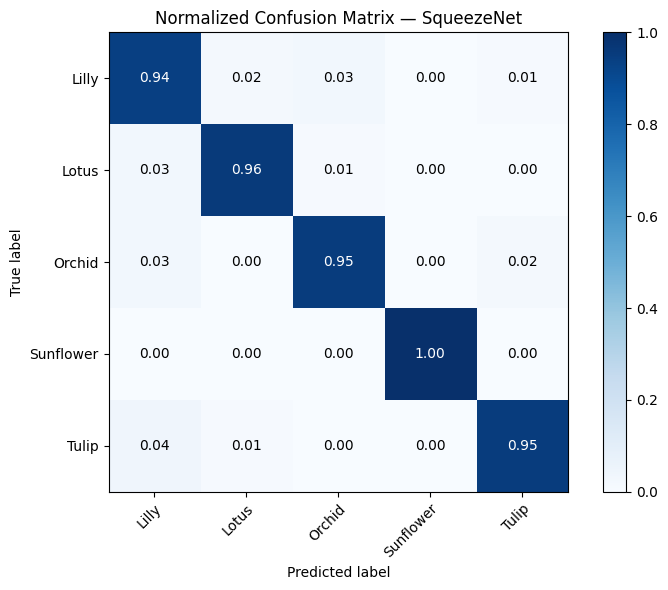

Classification Report:

              precision    recall  f1-score   support

       Lilly       0.90      0.94      0.92       100
       Lotus       0.97      0.96      0.96       100
      Orchid       0.96      0.95      0.95       100
   Sunflower       1.00      1.00      1.00       100
       Tulip       0.97      0.95      0.96       100

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



In [ ]:
import matplotlib.pyplot as plt

@torch.no_grad()
def get_all_preds_targets(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_targets.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

# Evaluate on test set
criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(net, test_loader, criterion)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}")

test_preds, test_targets = get_all_preds_targets(net, test_loader)

# Save the finetuned model (path/style like earlier)
model_path = "densenet_finetuned_flowers.pth"
torch.save(net.state_dict(), model_path)
print(f"Model saved to: {model_path}")

# Confusion matrix (normalized)
cm = confusion_matrix(test_targets, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(len(class_names)),
       yticks=np.arange(len(class_names)),
       xticklabels=class_names, yticklabels=class_names,
       ylabel='True label', xlabel='Predicted label',
       title='Normalized Confusion Matrix — SqueezeNet')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
# write values
thresh = cm_norm.max() / 2.
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print("Classification Report:\n")
print(classification_report(test_targets, test_preds, target_names=class_names))


## Visualize Predictions
Display a few **test images** with predicted labels (and softmax probabilities).


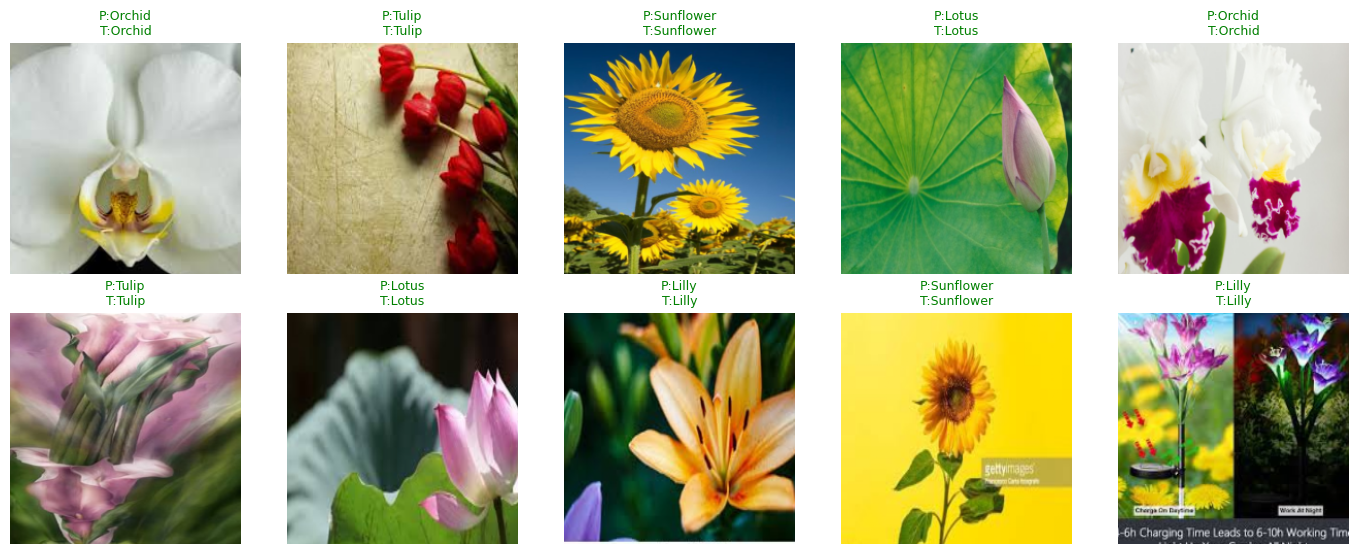

In [ ]:
# ---- Visualize a few predictions ----
import math, random
def denormalize(img_tensor, mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)):
    if isinstance(mean, tuple): mean = torch.tensor(mean, device=img_tensor.device).view(3,1,1)
    if isinstance(std, tuple):  std  = torch.tensor(std,  device=img_tensor.device).view(3,1,1)
    return (img_tensor * std + mean).clamp(0,1)

@torch.no_grad()
def show_predictions_balanced(model, dataset, class_names, k_per_class=2, max_total=12):
    model.eval()
    targets = dataset.targets if hasattr(dataset, "targets") else [y for _, y in dataset]
    per_class = {c: [] for c in range(len(class_names))}
    for idx, y in enumerate(targets):
        per_class[int(y)].append(idx)

    chosen = []
    for c in range(len(class_names)):
        pool = per_class[c]
        if pool:
            k = min(k_per_class, len(pool))
            chosen += random.sample(pool, k)
    random.shuffle(chosen)
    chosen = chosen[:max_total]

    imgs, labels = [], []
    for i in chosen:
        img, y = dataset[i]
        imgs.append(img); labels.append(y)
    if not imgs:
        print("No images sampled. Check dataset path.");
    else:
        batch = torch.stack(imgs).to(device)
        labels = torch.tensor(labels, device=device)
        preds = model(batch).argmax(1)

        n = len(imgs); cols = min(5, n); rows = math.ceil(n/cols)
        plt.figure(figsize=(2.8*cols, 2.8*rows))
        for i in range(n):
            plt.subplot(rows, cols, i+1)
            disp = denormalize(batch[i].cpu()).permute(1,2,0)
            p, t = class_names[preds[i].item()], class_names[labels[i].item()]
            plt.imshow(disp); plt.axis("off")
            plt.title(f"P:{p}\nT:{t}", fontsize=9, color=("green" if p==t else "red"))
        plt.tight_layout(); plt.show()

show_predictions_balanced(net, test_ds, class_names, k_per_class=2, max_total=20)


## DenseNet vs. AlexNet, VGG‑16, GoogLeNet, SqueezeNet, ResNet, **MobileNet** (Clear Summary)

- **Connections**  
  - *AlexNet/VGG*: Sequential layers (no skips).  
  - *GoogLeNet*: Multi‑branch Inception (parallel paths).  
  - *SqueezeNet*: 1×1 “squeeze” then 1×1/3×3 “expand” (Fire).  
  - *ResNet*: **Add** previous features via residual skip (elementwise sum).  
  - **DenseNet**: **Concatenate** *all* previous features within a block → powerful **feature reuse**.  
  - *MobileNet*: Replace standard conv with **depthwise** (per‑channel) + **pointwise 1×1** convs.

- **Parameters**  
  - VGG has **very many** parameters; SqueezeNet/MobileNet are **very small**; DenseNet/ResNet/GoogLeNet **balance** params & accuracy.  
  - DenseNet often matches/exceeds ResNet **with fewer parameters** due to reuse (depends on growth rate *k*).

- **Computation & Memory**  
  - Concatenation increases **channel count** → DenseNet uses **transition layers** to compress.  
  - MobileNet is the winner on **mobile/edge** due to depthwise separable convolutions.

- **Intuition**  
  - ResNet: *“Don’t forget important signals; add them forward.”*  
  - **DenseNet**: *“Reuse everything; keep features visible to all later layers.”*  
  - MobileNet: *“Do cheaper convolutions.”*

### Quick recap of **MobileNet** (for clarity)
- **Depthwise** conv filters each channel *independently* → **drastic FLOPs reduction**.  
- **Pointwise 1×1** conv mixes channels → restores representation power.  
- Variants (v1/v2/v3) add **inverted residuals**, **linear bottlenecks**, and **squeeze‑and‑excite** for better trade‑offs.



---

## What You Should Take Away
- **Dense connectivity** → strong feature reuse and gradient flow.  
- **Transition layers** keep the model compact while channel counts grow.  
- Using the **same flowers dataset** and **the same pipeline** as Practicals 7–12 gives a fair apples‑to‑apples comparison.

---

## Next Practical (14): EfficientNet
- **Focus**: compound scaling (depth/width/resolution) with MBConv+SE. We’ll fine-tune EfficientNet-B0 on the same flowers dataset using the same pipeline and evaluation.

---

> This practical was designed to give you hands-on experience with DenseNet - including dense blocks, growth rate (k), and transition layers - on the same flowers dataset, plus a clear comparison to **AlexNet**, **VGG-16**, **GoogLeNet**, **SqueezeNet**, **ResNet**, and **MobileNet**, and practical skills in fine-tuning pretrained models, inspecting parameters, probing feature shapes, and evaluating with a confusion matrix and classification report. The next practical will continue this progression with EfficientNet and compound scaling.
